# Posterior ratio test for recurrent convergence

In preliminary analyses, we have observed an inflation of infinite sites model (ISM) violations (i.e., somatic variants that evolve more than once within the population of hematopoietic progenitors). While the stochastic character mapping (SCM) model is permissive of such complex histories, violations of infinite sites are expected to be distributed (*somewhat*) randomly across the tree. Note that an exception to this expectation are lineages with elevated evolutionary rates which would subseqently be inflated for mutations with complex histories. 

## 1. Background

![SCM violations](figs/recurrent_violations.jpg)

In the figure above, we see three clades (color-coded) with two tips that display excess sharing of convergent mutations. The top panel is the maximum likelihood phylogenetic tree inferred using all somatic single nucleotide variants (scale bar is measured in substitutions per site). The bottom reflects principle component analysis performed on an $N \times K$ matrix, where $N$ are clones and $K$ is a boolean reflecting presence/absence of a somatic single nucleotide variant that has beem mapped to > one branch. Note that in this example, variants are assigned to any branch where $\mathrm{Pr(GT_{descendent}) \ge 0.95}$, $\mathrm{Pr(GT_{ancestor}) \ge 0.95}$, and $\mathrm{GT_{descendent} \ne \mathrm{GT_{ancestor}}}$.

A few patterns emerge when looking at pairs with repeated ISM-violation sharing. *First*, node supports for their alliance is sufficiently strong--supporting their phylogenetic alliance. *Second*, the edge length of the last common ancestor's lineage is often short. Given the continuous-time Markov model (approximated using a Poisson process) at the core of SCM, this short edge length depletes the "temporal" window in which a mutation can evolve. While this is not displayed on the figure, the *third* observation is that the SCM-approximated posterior probability of the derived genotype is often $0.95 > \mathrm{Pr} ≥ 0.50$. Thus, quantitative support for a single origin of the derived genotype state is present, though below the threshold for confident assignment.

## 2. Approach

Given a vector of genotype states $S = \{A, B, C\}$, the objective is to compare evidence for two competing hypotheses:
- $H_0$: Somatic single nucleotide variant $S_j$ was present in the last common ancestor to *Clone 1* and *Clone 2* and was inherited by both descendent lineages.
- $H_1$: Somatic single nucleotide variant $S_i$ was present in the last common ancestor, and $S_j$ evolved independently in *Clone 1* and *Clone 2*.

To quantitatively compare these hypotheses, we will quantify the posterior probability ratio $Pr(H_0 | \vec{\theta}) / Pr(H_1 | \vec{\theta})$, where $\vec{\theta}$ is a placeholder for the following parameters:
- $\tau$: Maximum-likelihood phylogenetic tree with informative branch lengths $v$
- $\boldsymbol{Q}$: Substitution matrix jointly fit to $\tau$
- $S$: All possible genotype states given alleles observed at the locus

Along any arbitrary branch $v$, the probability of a genotype state transition between states $S_i$ and $S_j$ is given by $p_{ij}(v) = e^{\boldsymbol{Q}v}$. From SCM, we approximate the posterior probability of the last common ancestor possessing the derived genotype state $S_j$ and can use this an informed prior, 

$$
\mathrm{Pr}(\vec{\theta}) = \mathrm{Pr_{SCM}}(GT_{LCA} = S_j).
$$ 

Thus, we can compute the posterior odds of $H_1 / H_0$ as the following beginning with Bayes theorem:

$$
\begin{align*}
\frac{\mathrm{Pr}(H_1|\vec{\theta})}
     {\mathrm{Pr}(H_0|\vec{\theta})}
        &= \frac{\mathrm{Pr}(\vec{\theta}|H_1) \times \mathrm{Pr_{SCM}}(GT_{LCA} \ne S_j)}
                {\mathrm{Pr}(\vec{\theta}|H_0) \times \mathrm{Pr_{SCM}}(GT_{LCA} = S_j)} \\
        &= \frac{\left(\displaystyle\prod_{l \in v_1, v_2} p_{ij}(v_l)\right) \times p_{ii}(v_3) \times \mathrm{Pr_{SCM}}(GT_{LCA} \ne S_j)}
                {\left(\displaystyle\prod_{l \in v_1, v_2} p_{jj}(v_l)\right) \times p_{ij}(v_3) \times \mathrm{Pr_{SCM}}(GT_{LCA} = S_j)}
\end{align*}
$$

Given that there are multiple genotype state transition paths to yeild state $S_j$ (particularly when $S_j$ is not well-resolved), we can sum across each genotype state transition path and take the product across independently evolving lineages. This most comprehensively approximates the likelihood of the data under each hypothesis (*equation 1*):

$$
\begin{align}
\frac{\mathrm{Pr}(H_1|\vec{\theta})}
     {\mathrm{Pr}(H_0|\vec{\theta})}
        &= \frac{\left(\displaystyle\prod_{l \in v_1, v_2} \displaystyle\sum_{i \in S, j = S_j, i \ne j} p_{ij}(v_l)\right) \times \left(\displaystyle\sum_{i \in S, i \ne j} p_{ii}(v_3)\right) \times \mathrm{Pr_{SCM}}(GT_{LCA} \ne S_j)}
                {\left(\displaystyle\prod_{l \in v_1, v_2} p_{jj}(v_l)\right) \times \left(\displaystyle\sum_{i \in S, j = S_j, i \ne j} p_{ij}(v_3)\right) \times \mathrm{Pr_{SCM}}(GT_{LCA} = S_j)} \\
\end{align}
$$

***Note that the equation (1) above needs to be validated to accurately represent the sum across marginalized transition states for each value of $i$ and $j$. In practice, we only need to consider the observed genotype states, not all 10 unphased states. Nonetheless, the equation above should be adjusted accordingly***

To provide an intution of this approch, consider the following toy example based on empirical observations. In this example, I've expanded Bayes theorem for each component hypothesis. In the figure below, colors reflect each hypothesis

![Toy example](figs/toy_example.png)

While the diagram above represents a case for only two descendent lineages, *equation 1* is compatible with any number of descendent lineages and mutational patterns across these lineages; however, the complexity of system increases dramatically. 

Importantly, this Bayesian framework is compatible with sharing evidence across independently evolving sites. As convergent mutations are not expected to be correlated between any set of lineages, repeated observations favor single origin + technical uncertainty ($H_0$) over repeated convergence ($H_1$). Thus, we can visually represent the effect of accumulated evidence on the posterior ratio as the following (here, colors represent independently evolving somatic variants):

![Aggregating evidence across sites](figs/integrating_across_observations.jpg)

Finally, this schematic can be used to expand *equation 1* to incorporate evidence across independently evolving SNVs.

$$
\begin{align}
\tag{2}
\frac{\mathrm{Pr}(H_1|\vec{\theta})}
     {\mathrm{Pr}(H_0|\vec{\theta})}
= \prod_{m \in \mathrm{SNV_{\mathit{H_1}}}}
    \left[
        \frac{\left(\displaystyle\prod_{l \in v_1, v_2} \displaystyle\sum_{i \in S, j = S_j, i \ne j} p_{ij}(v_l)\right) \times \left(\displaystyle\sum_{i \in S, i \ne j} p_{ii}(v_3)\right) \times \mathrm{Pr_{SCM}}(GT_{LCA} \ne S_j)}
                {\left(\displaystyle\prod_{l \in v_1, v_2} p_{jj}(v_l)\right) \times \left(\displaystyle\sum_{i \in S, j = S_j, i \ne j} p_{ij}(v_3)\right) \times \mathrm{Pr_{SCM}}(GT_{LCA} = S_j)}
    \right]
\end{align}
$$

# 3. Simulation

To generate some expectations of how this method will behave, below are some simulated results across a distribution of parameter values. Among these, we will test the effects of the following:
1. $GT_{LCA}$ **prior probabilities**
2. $v_{LCA} / \sum v_{clade}$, the ratio of branch lengths between LCA and descendents
3. **Observation count** (i.e., number of violations)
4. **Mutation class** (e.g., C>T vs. A>G)

# 3.1 Data generation

,AA,CC,GG,TT,AC,AG,AT,CG,CT,GT
AA,-0.1578658,0.0010000,0.0010000,0.0010000,0.01732493,0.09642825,0.03811257,0.00100000,0.00100000,0.00100000
CC,0.0010000,-0.1271676,0.0010000,0.0010000,0.01732493,0.00100000,0.00100000,0.01028200,0.09356066,0.00100000
GG,0.0010000,0.0010000,-0.1279017,0.0010000,0.00100000,0.09642825,0.00100000,0.01028200,0.00100000,0.01519146
TT,0.0010000,0.0010000,0.0010000,-0.1528647,0.00100000,0.00100000,0.03811257,0.00100000,0.09356066,0.01519146
AC,0.3127298,0.5688660,0.0010000,0.0010000,-1.11447674,0.03710500,0.02534099,0.02672080,0.14071422,0.00100000
AG,0.4105133,0.0010000,0.7298453,0.0010000,0.00875100,-1.22110136,0.02080011,0.02035595,0.00100000,0.02783569
AT,0.5501074,0.0010000,0.0010000,0.5515422,0.02026306,0.07052158,-1.29620084,0.00100000,0.07999442,0.02077216
CG,0.0010000,0.2873400,0.2808400,0.0010000,0.02274205,0.07345922,0.00100000,-0.76268461,0.07679544,0.01850790
CT,0.0010000,0.6653398,0.0010000,0.3667195,0.03047543,0.00100000,0.02166656,0.01954192,-1.11473623,0.00799300
GT,0.0010000,0.0010000,0.5337631,0.3010067,0.00100000,0.12921846,0.02844120,0.02380811,0.04040600,-1.05964361


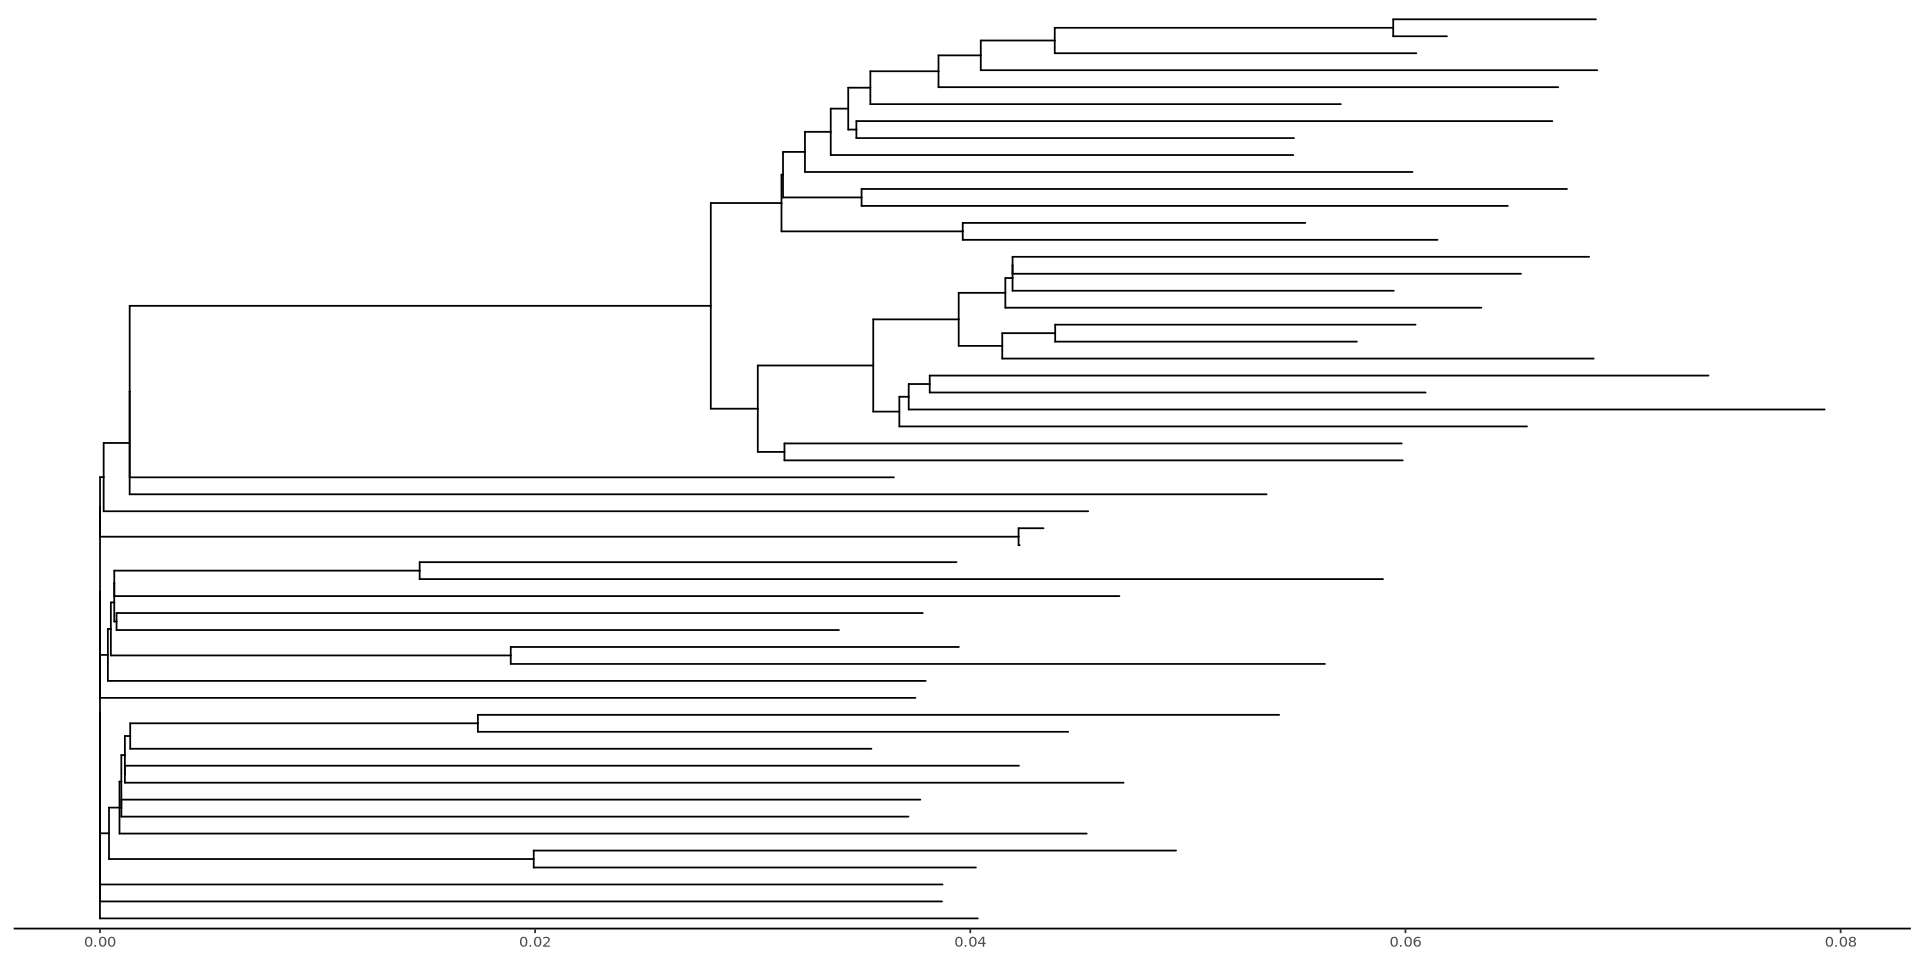

In [119]:
# Load libraries
suppressPackageStartupMessages(
    source("../dev/bin/SCM_functions.R")
)

# Read a substitution model
Q <- read_cellphy_model("../dev/data/test.vcf.cellphy.raxml.bestModel")
Q
# Read a tree
tr <- read.tree(file = "../dev/data/test.vcf.cellphy.raxml.supportFBP") %>% drop.tip("outgroup")
ggtree(tr) + theme_tree2()

In [120]:
# Write function for computing mutation likelihood along a branch
suppressPackageStartupMessages(library(expm))
mutL <- function(Q, anc_genotype, desc_genotype, branch_length, log = TRUE) {
    if (!(anc_genotype %in% colnames(Q)) | !(desc_genotype %in% colnames(Q))) {
        stop("Genotype not found in Q matrix")
    }
    p <- expm(Q * branch_length)[anc_genotype, desc_genotype]
    if (log) {
        p <- log(p)
    }
    return(p)
}

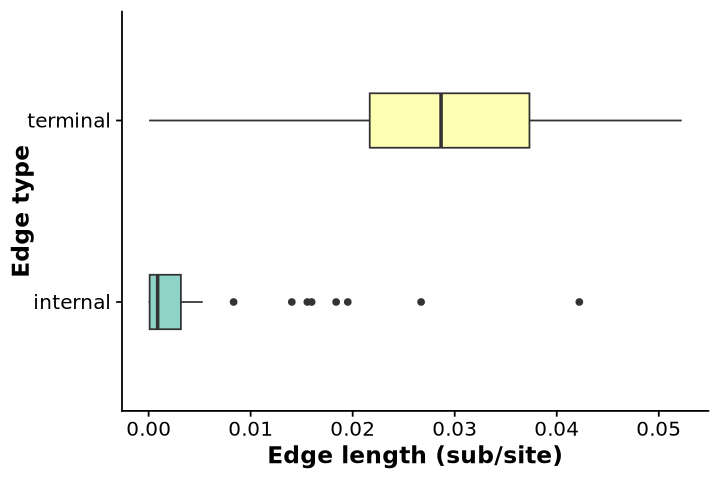

In [121]:
# Plot distribution of terminal branch lengths
options(repr.plot.width = 6, repr.plot.height = 4)
terminal_edge_lengths <- tr$edge.length[which(tr$edge[,2] <= length(tr$tip.label))]
internal_edge_lengths <- tr$edge.length[which(tr$edge[,2] > length(tr$tip.label))]

data.frame(length = c(terminal_edge_lengths,internal_edge_lengths),
           type = rep(c("terminal", "internal"), c(length(terminal_edge_lengths), length(internal_edge_lengths)))) %>%
    ggplot(aes(x = length, fill = type, y = type)) +
    geom_boxplot(width = 0.3) + 
    scale_fill_brewer(palette = "Set3", guide = "none") +
    theme_cowplot() +
    theme(axis.title = element_text(face = "bold")) +
    labs(x = "Edge length (sub/site)", y = "Edge type")

In [122]:
# Compute 95% CI for terminal and internal edge-lengths
term_ci <- quantile(terminal_edge_lengths, probs = c(0.025, 0.975))
int_ci <- quantile(internal_edge_lengths, probs = c(0.025, 0.975))

In [161]:
# Create null distributions for testing
set.seed(420)
options(repr.plot.width = 12, repr.plot.height = 6)

## Create data frame
priors <- round(seq(0, 1, length.out = 101), 2)

df <- expand.grid(
    prior = priors,
    internal = seq(from = int_ci[1], to = int_ci[2], length.out = 50) 
)

df$terminal_95low <- term_ci[1]
df$terminal_med <- median(terminal_edge_lengths)
df$terminal_95high <- term_ci[2]

df <- df %>% 
    pivot_longer(cols = c("terminal_95low", "terminal_med", "terminal_95high"), names_to = "terminal", values_to = "terminal_length")

head(df)

prior,internal,terminal,terminal_length
<dbl>,<dbl>,<chr>,<dbl>
0.00,1e-06,terminal_95low,0.001576325
0.00,1e-06,terminal_med,0.028662500
0.00,1e-06,terminal_95high,0.046097150
0.01,1e-06,terminal_95low,0.001576325
0.01,1e-06,terminal_med,0.028662500
0.01,1e-06,terminal_95high,0.046097150


In [162]:
## Compute statistics
### numerator = two independent origins
### denominator = single origin in ancestor
pbmclapply(X = seq(1,nrow(df)), FUN = function(i) {
    row <- df[i, ]
    
    # Compute stats
    ## Posterior ratio
    bayes_recurrent <- sum(c(mutL(Q, anc_genotype = "CC", desc_genotype = "CC", branch_length = row$internal),
                             mutL(Q, anc_genotype = "CC", desc_genotype = "CT", branch_length = row$terminal_length),
                             mutL(Q, anc_genotype = "CC", desc_genotype = "CT", branch_length = row$terminal_length),
                             log10(row$prior)))
    bayes_single <- sum(c(mutL(Q, anc_genotype = "CC", desc_genotype = "CT", branch_length = row$internal),
                          mutL(Q, anc_genotype = "CT", desc_genotype = "CT", branch_length = row$terminal_length),
                          mutL(Q, anc_genotype = "CT", desc_genotype = "CT", branch_length = row$terminal_length),
                          log10(1 - row$prior)))
    logPratio <- bayes_recurrent - bayes_single

    ## Likelihood ratio
    L_recurrent <- sum(c(mutL(Q, anc_genotype = "CC", desc_genotype = "CC", branch_length = row$internal),
                         mutL(Q, anc_genotype = "CC", desc_genotype = "CT", branch_length = row$terminal_length),
                         mutL(Q, anc_genotype = "CC", desc_genotype = "CT", branch_length = row$terminal_length)))
    L_single <- sum(c(mutL(Q, anc_genotype = "CC", desc_genotype = "CT", branch_length = row$internal),
                        mutL(Q, anc_genotype = "CT", desc_genotype = "CT", branch_length = row$terminal_length),
                        mutL(Q, anc_genotype = "CT", desc_genotype = "CT", branch_length = row$terminal_length)))
    logLratio <- L_recurrent - L_single

    # Add to data frame
    row$bayes_recurrent <- bayes_recurrent
    row$bayes_single <- bayes_single
    row$logPratio <- logPratio
    row$L_recurrent <- L_recurrent
    row$L_single <- L_single
    row$logLratio <- logLratio

    # Return row
    return(row)
}) %>% bind_rows() -> df
head(df)

prior,internal,terminal,terminal_length,bayes_recurrent,bayes_single,logPratio,L_recurrent,L_single,logLratio
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
0.00,1e-06,terminal_95low,0.001576325,-Inf,-16.18817,-Inf,-17.64551,-16.18817,-1.457338
0.00,1e-06,terminal_med,0.028662500,-Inf,-16.24847,-Inf,-11.87707,-16.24847,4.371405
0.00,1e-06,terminal_95high,0.046097150,-Inf,-16.28720,-Inf,-10.94760,-16.28720,5.339600
0.01,1e-06,terminal_95low,0.001576325,-19.64551,-16.19254,-3.452973,-17.64551,-16.18817,-1.457338
0.01,1e-06,terminal_med,0.028662500,-13.87707,-16.25284,2.375769,-11.87707,-16.24847,4.371405
0.01,1e-06,terminal_95high,0.046097150,-12.94760,-16.29157,3.343965,-10.94760,-16.28720,5.339600


In [163]:
df.summary <- df %>%
    pivot_longer(cols = c("logPratio", "logLratio"), names_to = "metric", values_to = "value") %>%
    select(prior, terminal, internal, metric, value) %>%
    pivot_wider(names_from = terminal, values_from = value)

head(df.summary)

prior,internal,metric,terminal_95low,terminal_med,terminal_95high
<dbl>,<dbl>,<chr>,<dbl>,<dbl>,<dbl>
0.00,1e-06,logPratio,-Inf,-Inf,-Inf
0.00,1e-06,logLratio,-1.457338,4.371405,5.339600
0.01,1e-06,logPratio,-3.452973,2.375769,3.343965
0.01,1e-06,logLratio,-1.457338,4.371405,5.339600
0.02,1e-06,logPratio,-3.147534,2.681209,3.649404
0.02,1e-06,logLratio,-1.457338,4.371405,5.339600


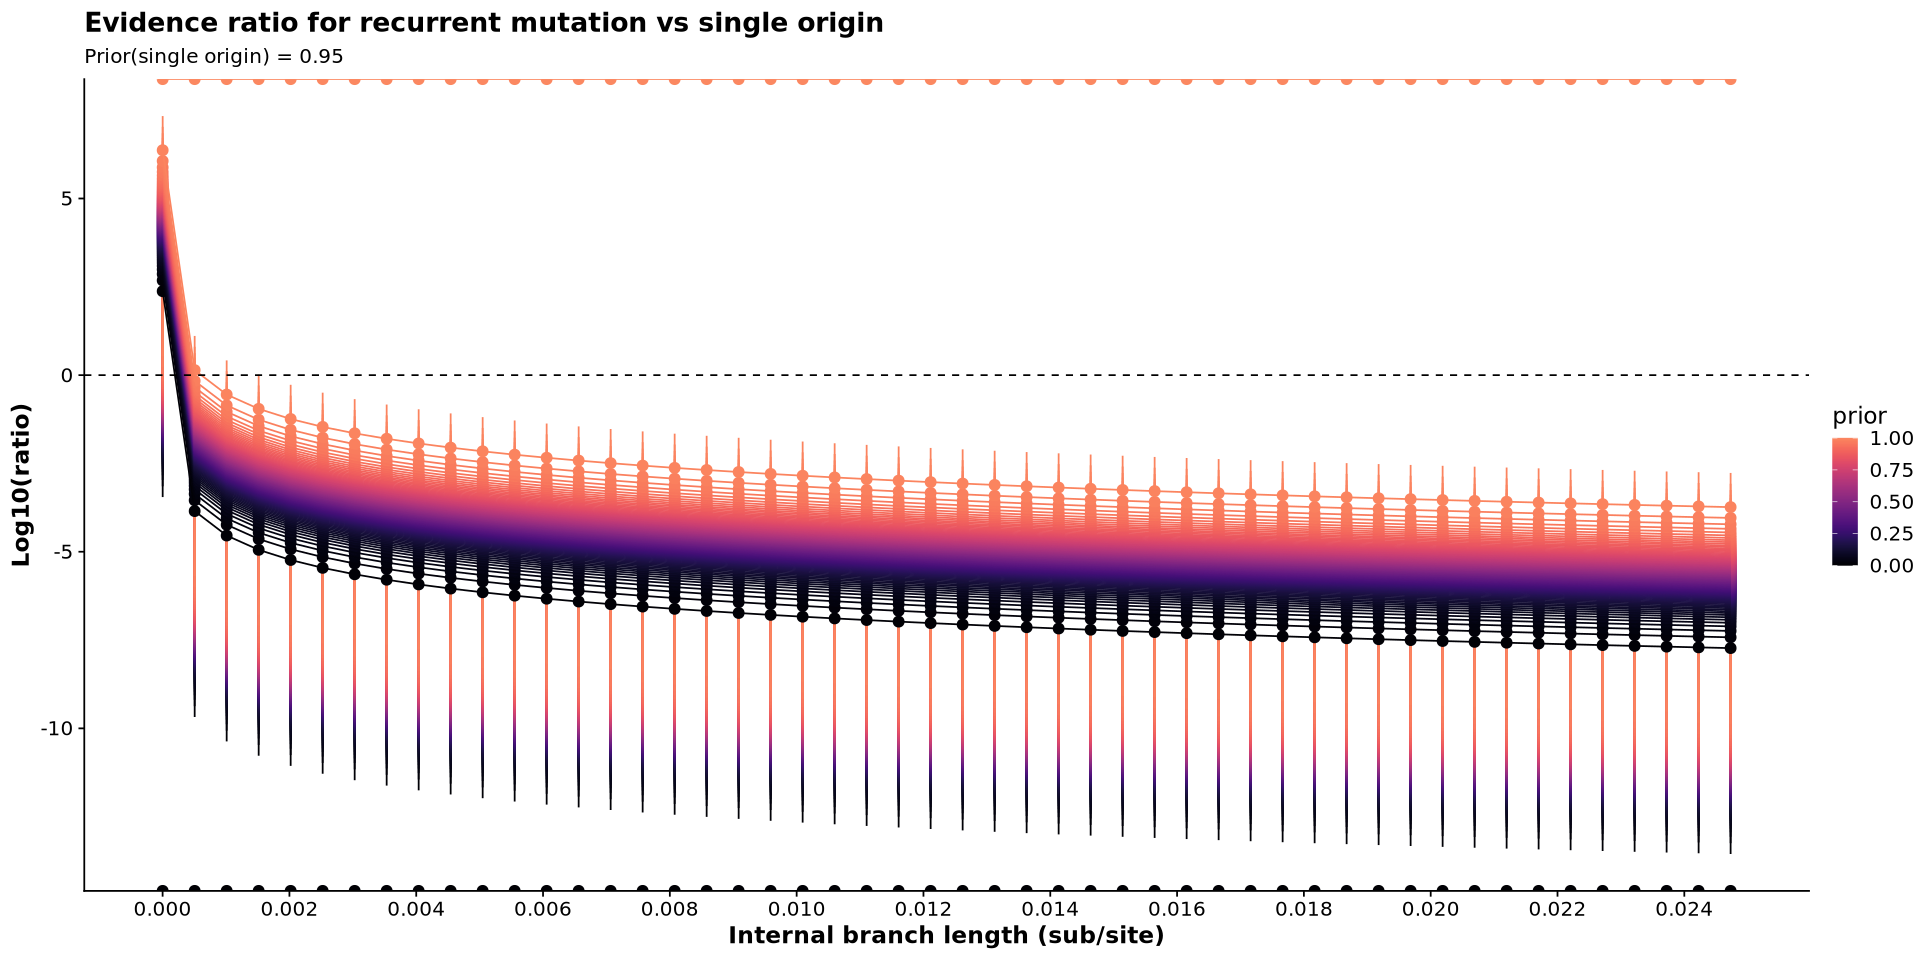

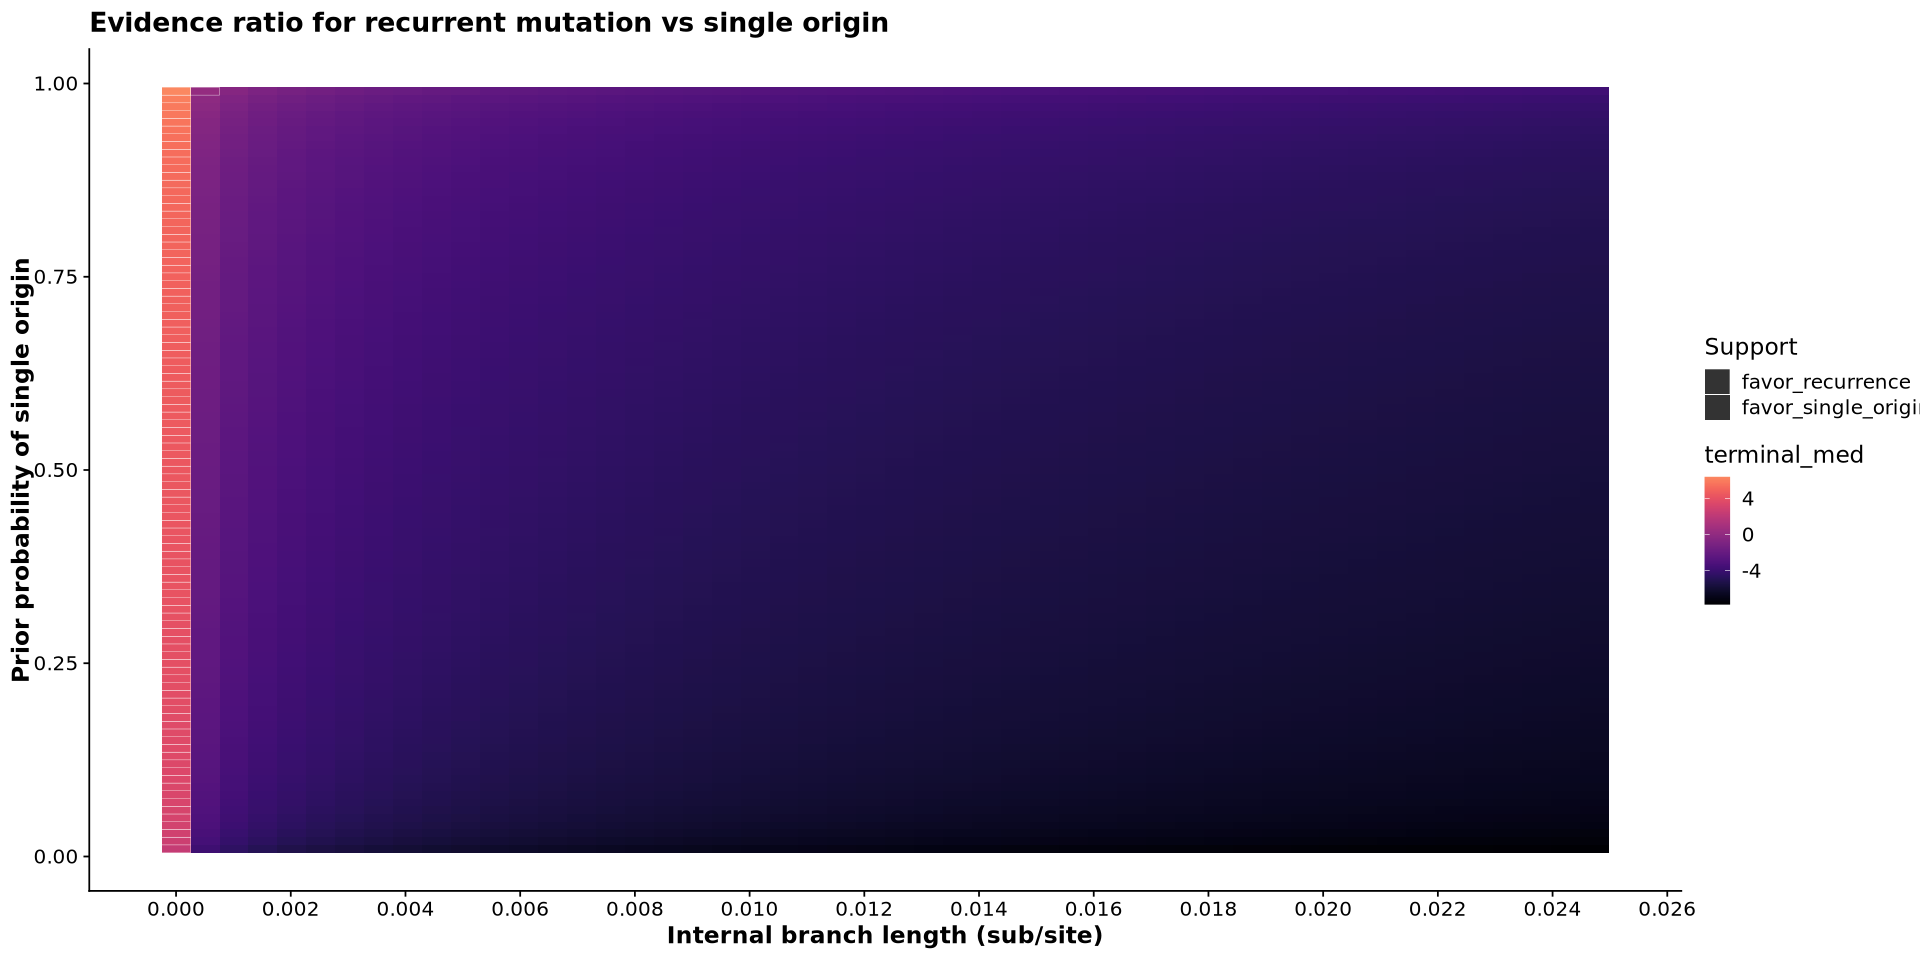

In [ ]:
# Create plots
options(repr.plot.width = 16, repr.plot.height = 8)

# df.summary %>%
#     ggplot(aes(x = internal, y = terminal_med, color = prior)) +
#     geom_pointrange(aes(ymin = terminal_95low, ymax = terminal_95high), 
#                     shape = 21,
#                     fill = "white") +
#     geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
#     facet_wrap(~ metric, nrow = 1) +
#     scale_color_viridis(option = "magma", end = 0.75) +
#     theme_cowplot() +
#     theme(strip.background = element_blank(),
#           strip.text = element_text(face = "bold"),
#           axis.title = element_text(face = "bold")) +
#     labs(y = "Log10(ratio)", x = "Internal branch length (sub/site)", title = "Evidence ratio for recurrent mutation vs single origin")

df.summary %>%
    filter(metric == "logPratio") %>% 
    ggplot(aes(x = internal, y = terminal_med, color = prior)) +
    geom_pointrange(aes(ymin = terminal_95low, ymax = terminal_95high)) +
    geom_line(aes(group = prior)) +
    geom_hline(yintercept = 0, linetype = "dashed", color = "black") +
    scale_x_continuous(breaks = scales::pretty_breaks(n = 10)) +
    scale_color_viridis(option = "magma", end = 0.75) +
    theme_cowplot() +
    theme(strip.background = element_blank(),
          strip.text = element_text(face = "bold"),
          axis.title = element_text(face = "bold")) +
    labs(y = "Log10(ratio)",
         x = "Internal branch length (sub/site)",
         title = "Evidence ratio for recurrent mutation vs single origin",
         subtitle = "Prior(single origin) = 0.95")

df.summary %>%
    filter(metric == "logPratio", !prior %in% c(0,1)) %>% 
    mutate(support_conv = ifelse(terminal_med > 0, "favor_recurrence", "favor_single_origin")) %>%
    ggplot(aes(x = internal, y = prior, fill = terminal_med, color = support_conv)) +
    geom_tile() +
    scale_fill_viridis(option = "magma", end = 0.75) +
    scale_color_manual(values = c("favor_recurrence" = "white", "favor_single_origin" = "transparent"), name = "Support") +
    scale_x_continuous(breaks = scales::pretty_breaks(n = 10)) +
    theme_cowplot() +
    theme(axis.title = element_text(face = "bold")) +
    labs(y = "Prior probability of single origin",
         x = "Internal branch length (sub/site)",
         title = "Evidence ratio for recurrent mutation vs single origin")

Result above is unexepeted, as the SCM results suggest that the two independent origins would be favored over the single origin in the ancestor (higher Bayes factors favor the single origin) when only one site is considered.

However, an issue with the test above is that the joint-likelihood is computed across a different number of branches. The numerator (single origin) incorporates a single likelihood compute, whereas the denominator incorporates two tests. Below, we will adjust the algorithm to accommodate a equal number of tests for both scenario:

$$
\begin{align*}
\frac{\mathrm{Pr}(H_1|\vec{\theta})}
     {\mathrm{Pr}(H_0|\vec{\theta})}
        &= \frac{e^{\boldsymbol{Q_{jj}}{v_1}} \times e^{\boldsymbol{Q_{jj}}{v_2}} \times e^{\boldsymbol{Q_{ij}}{v_3}} \times \mathrm{Pr_{SCM}}(GT_{LCA} = S_j)}
                {e^{\boldsymbol{Q_{ij}}{v_1}} \times e^{\boldsymbol{Q_{ij}}{v_2}} \times e^{\boldsymbol{Q_{ii}}{v_3}} \times \mathrm{Pr_{SCM}}(GT_{LCA} \ne S_j)} \\
\end{align*}
$$